In [1]:
#Set up paths
import sys
import os

from Utils import utils as uti

from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import MyConstants as Co


import regrid_wavecube as rwv


# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import pywt

# Cartopy for pretty maps
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Some other useful packages 
import importlib
import copy
import time
import cftime
import yaml
import glob
#from box import Box #???

importlib.reload( rwv )
importlib.reload(MkP)
importlib.reload(GrU)

pi_ = Co.pi()
R_earth = Co.Rearth()

print( R_earth )

 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
6378137.0


In [2]:
import glob
import os

pattern = '/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-*.nc'
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} files")



Found 124 files


In [3]:
#print( files )
X=xr.open_dataset( files[0] )
print( X.sizes['lat'] )
print( X.lat[300].values )
nt,nz,ny,nx= len(files),X.sizes['lev'],X.sizes['lat'],X.sizes['lon'] 
print( nt,nz,ny,nx )
wp_tyx=np.zeros( (nt,ny,nx ) )
wp_tzx=np.zeros( (nt,nz,nx ) )

tbk_tzx = np.zeros( (nt,nz,nx ) )
ubk_tzx = np.zeros( (nt,nz,nx ) )
time_vals=[]


1440
-52.4375
124 93 1440 2880


In [4]:
n=0
lat_sel = -52.4
for f in files:
    X=xr.open_mfdataset(f , data_vars='different', coords='different' , compat='no_conflicts' )
    wp_ =X.wp.isel(lev=20).values
    wp_tyx[n,:,:] = wp_
    wp_ =X.wp.sel(lat=lat_sel,method='nearest').values
    wp_tzx[n,:,:] = wp_

    a_ =X.Tbk.sel(lat=lat_sel,method='nearest').values
    tbk_tzx[n,:,:] = a_

    a_ =X.Ubk.sel(lat=lat_sel,method='nearest').values
    ubk_tzx[n,:,:] = a_

    time_vals.append( X.time.values )
    n=n+1
    if (n%10==0):
        print( f )

/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-03-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-05-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-08-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-10-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-13-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-15-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/

In [5]:
print( len(time_vals) , time_vals[13] )

124 [cftime.DatetimeNoLeap(2004, 7, 4, 6, 0, 0, 0, has_year_zero=True)]


In [6]:

plev=X.lev.values
lon=X.lon.values
zlev= -7_000.*np.log( plev/1000. )
print( zlev[10] )

43894.71084178742


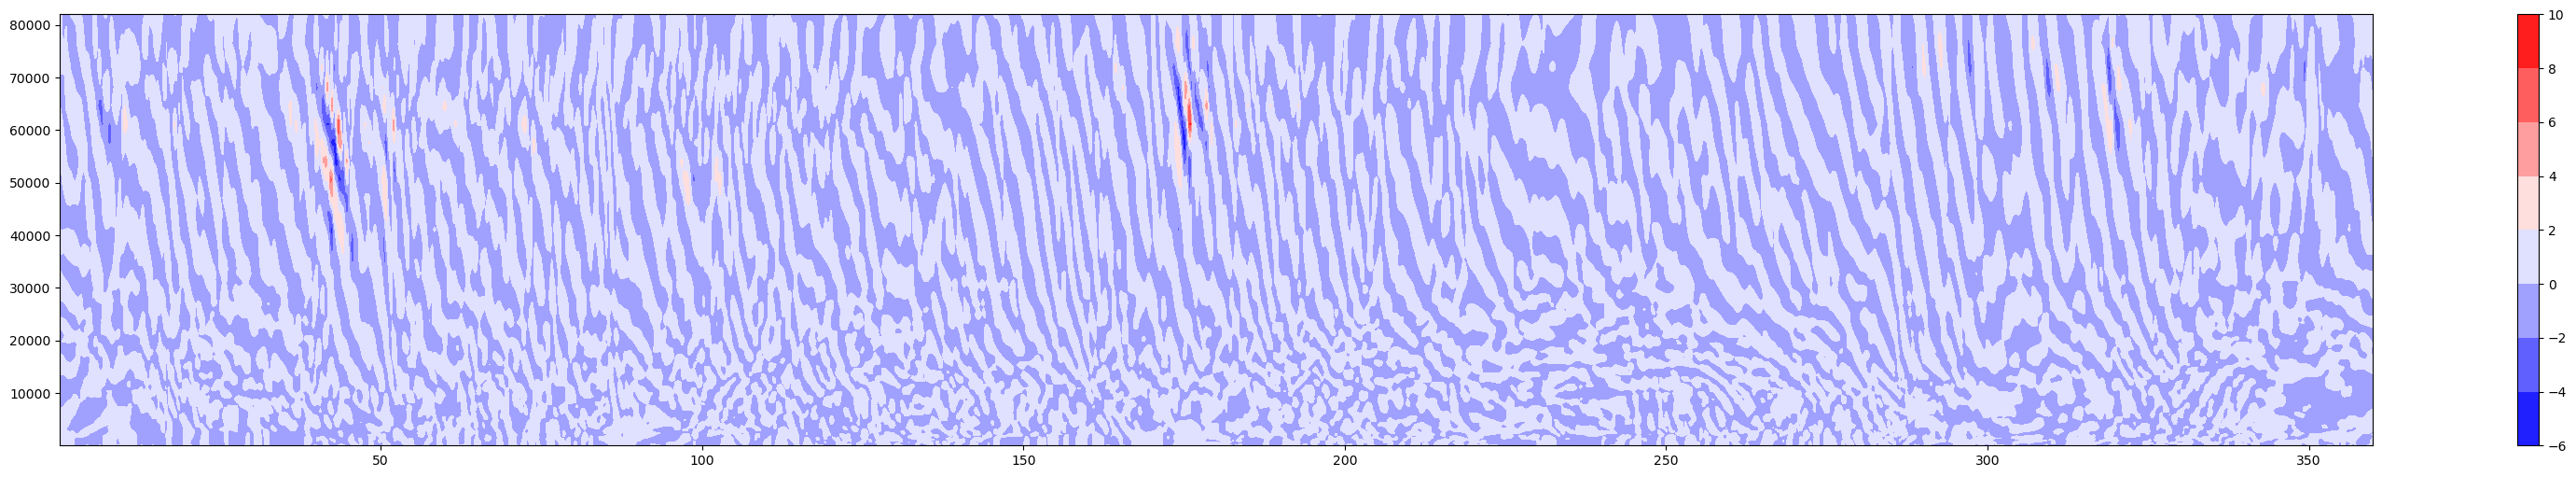

In [7]:
fig,ax=plt.subplots( 1,1 , figsize=(40,6) )
c=ax.contourf( lon,zlev,wp_tzx[13,:,:] , cmap='bwr' )
plt.colorbar( c )

In [8]:
from Regridder import VertRegridFlexLL as vrg

#zSrc=np.zeros( (nt,nz,nx ) )

nz_m=128
zlev_m = np.linspace( 0., zlev[0], num=nz_m )

zSrc = zlev[None, :, None]
zSrc = np.broadcast_to(zlev[None, :, None], (nt, nz, nx))
zDst = zlev_m[None, :, None]
zDst = np.broadcast_to(zlev_m[None, :, None], (nt, nz_m, nx))

#plt.contourf( zSrc[15,:,:] )
#plt.colorbar()

wp_tzx_m = vrg.VertRG( a_x=wp_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )
ubk_tzx_m = vrg.VertRG( a_x=ubk_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )
tbk_tzx_m = vrg.VertRG( a_x=tbk_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )




Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 7.8757 seconds
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 7.9922 seconds
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 7.8342 seconds


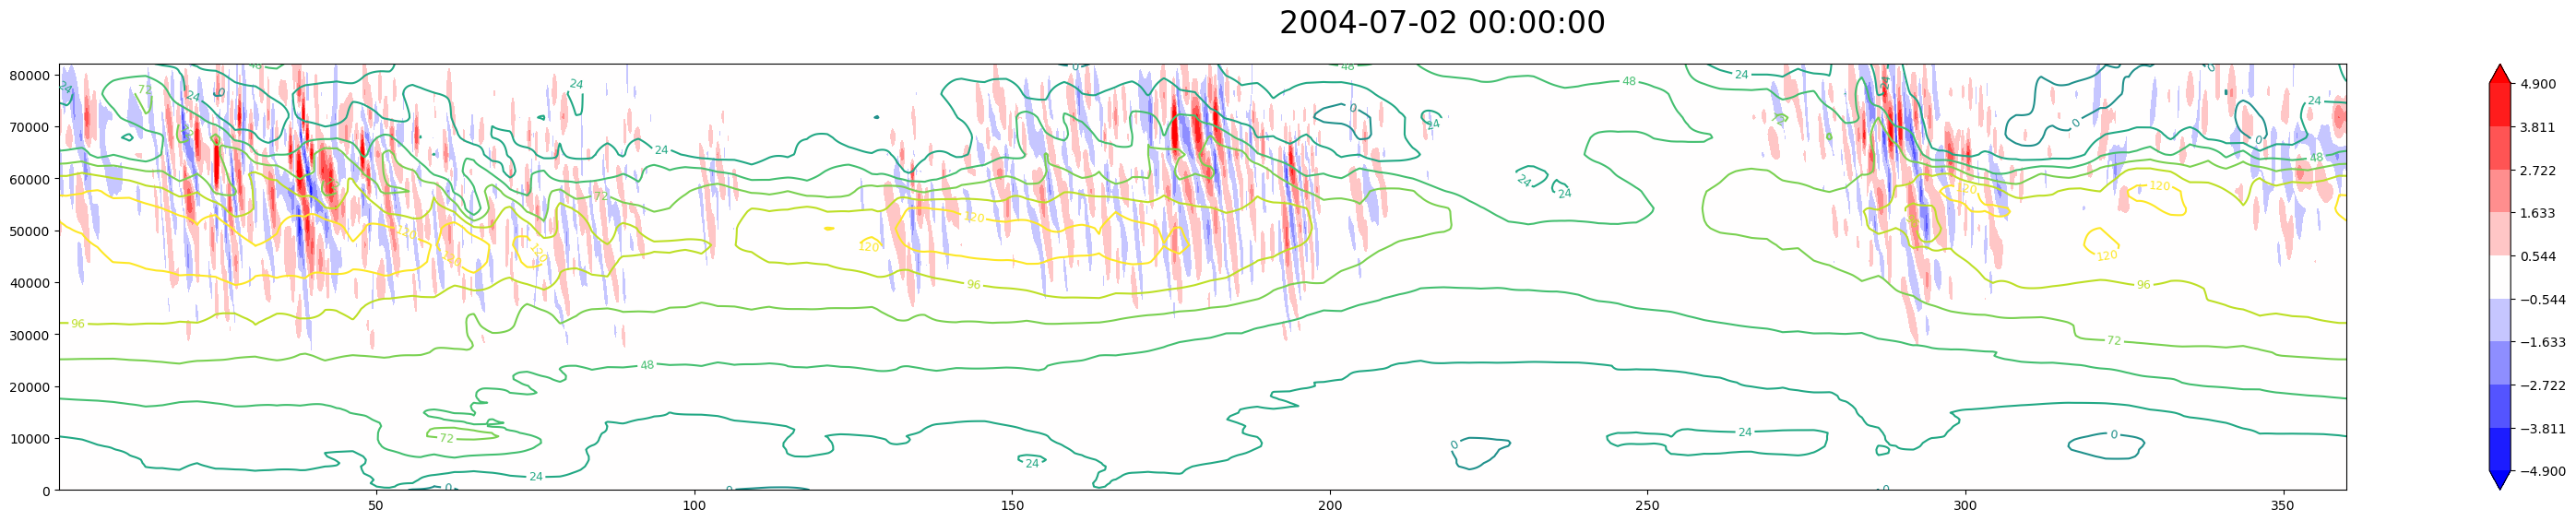

In [9]:
t=8
timething= time_vals[4].item().strftime("%Y-%m-%d %H:%M:%S")

fig,ax=plt.subplots( 1,1 , figsize=(40,6) )
c=ax.contourf( lon,zlev_m,wp_tzx_m[t,:,:] , cmap='bwr' ,levels=np.linspace(-4.9,4.9, 10 ), extend='both' )
l=ax.contour( lon,zlev_m,ubk_tzx_m[t,:,:] , levels=np.linspace(-120.,120., 11 ) )
ax.clabel(l, inline=True, fontsize=9, fmt="%.0f")
plt.suptitle( f'{timething}' ,fontsize=24)
#ax.set_xlim(0,100)
plt.colorbar( c )

In [14]:
print( np.shape(wp_tzx_m))
print( zlev_m[80])

(124, 128, 2880)
51676.00535945456


In [16]:

wp_tzx_m_dwt = wp_tzx_m[:,80,:]



wp2 = pywt.WaveletPacket2D(data=wp_tzx_m_dwt , wavelet='db4', maxlevel=3)



#print( X.time.values )

In [33]:
wavelet = "db4"
mode = "symmetric"     # safe default for nonperiodic boundaries

cA, (cH, cV, cD) = pywt.dwt2(wp_tzx_m_dwt, wavelet=wavelet, mode=mode)


In [48]:
def pack_level1(cA, cH, cV, cD):
    nx, ny = cA.shape
    out = np.zeros((2*nx, 2*ny))
    out[:nx, :ny] = cA        # LL
    out[:nx, ny:] = cH        # LH
    out[nx:, :ny] = cV        # HL
    out[nx:, ny:] = cD        # HH
    return out


In [49]:
packed = pack_level1(cA, cH, cV, cD)

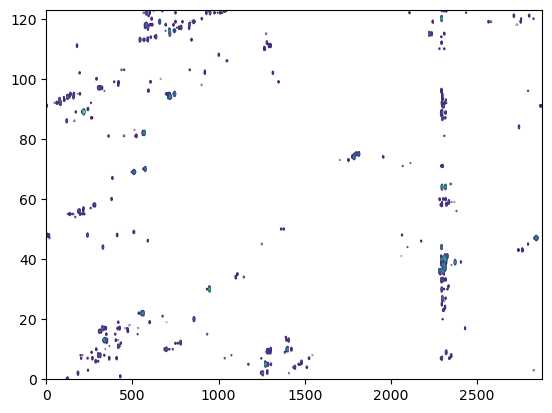

In [57]:
plt.contour( wp_tzx_m_dwt**2 )

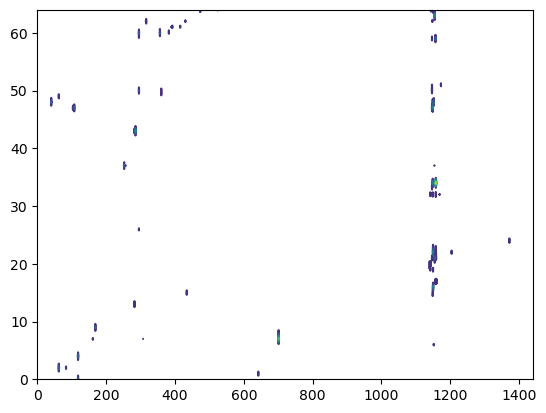

In [56]:
plt.contour( cV**2 )

In [18]:
def wp2_energy_quilt(wp2, level, order="freq", normalize=True, title=None):
    nodes = wp2.get_level(level, order=order)
    E = np.array([np.mean(n.data.astype(np.float64)**2) for n in nodes])  # energy per node

    # Arrange as 2^level x 2^level grid (because nodes = 4^level)
    nside = 2**level
    Egrid = E.reshape(nside, nside)

    if normalize:
        Egrid = Egrid / (Egrid.max() if Egrid.max() != 0 else 1.0)

    fig, ax = plt.subplots()
    im = ax.imshow(Egrid, origin="lower", aspect="equal")
    plt.colorbar(im, ax=ax, label="normalized energy" if normalize else "energy")

    ax.set_xlabel("subband index (order depends on 'order')")
    ax.set_ylabel("subband index")
    ax.set_title(title or f"Wavelet packet energy quilt (level={level}, order={order})")
    #plt.show()

    return Egrid


In [22]:
nodes = wp2.get_level(level=3, order="freq")

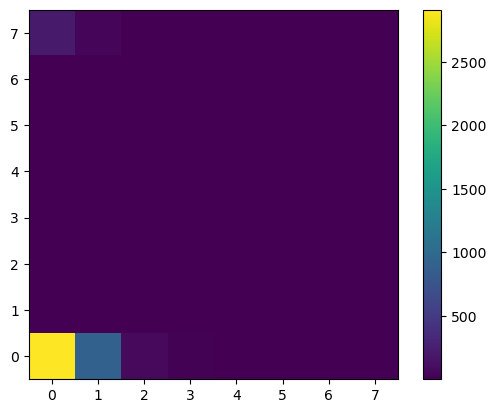

In [27]:
nodes2d = wp2.get_level(level=3, order="freq")   # shape: (2**level, 2**level) lists of Node2D

Egrid = np.array([
    [np.mean(node.data.astype(np.float64)**2) for node in row]
    for row in nodes2d
])
fig, ax = plt.subplots()
im = ax.imshow(Egrid, origin="lower", aspect="equal")
plt.colorbar(im, ax=ax, ) #label="normalized energy" if normalize else "energy")


In [28]:
def show_tile(nodes2d, iy, ix, title=None):
    node = nodes2d[iy][ix]
    A = node.data
    fig, ax = plt.subplots()
    im = ax.imshow(A, origin="lower", aspect="auto")
    plt.colorbar(im, ax=ax, label="coeff")
    ax.set_title(title or f"tile (y,x)=({iy},{ix}), path='{node.path}', shape={A.shape}")
    #plt.show()
    return node


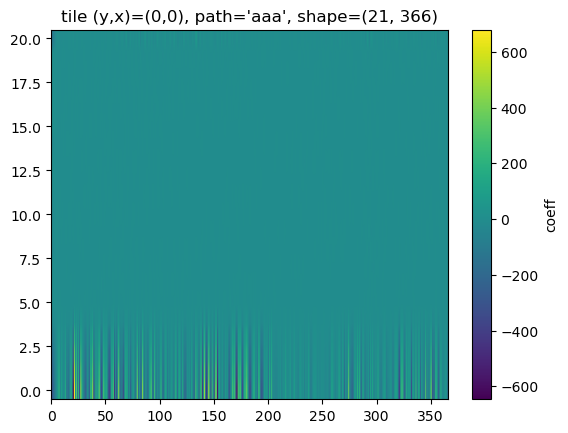

In [29]:
n00 = show_tile(nodes2d, 0, 0)

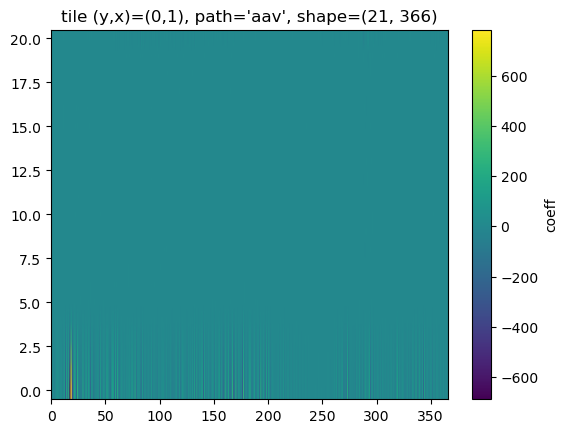

In [30]:
n01 = show_tile(nodes2d, 0, 1)

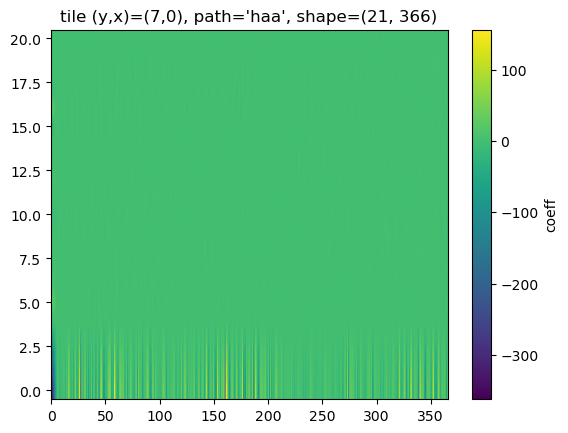

In [31]:
n70 = show_tile(nodes2d, 7, 0)

In [24]:
E = np.array([np.mean(n.data.astype(np.float64)**2) for n in nodes])

AttributeError: 'list' object has no attribute 'data'

In [19]:
Egrid = wp2_energy_quilt(wp2, level=3, order="freq", normalize=True)


AttributeError: 'list' object has no attribute 'data'

In [ ]:
#print(zlev_m[0:5]-zlev_m[1:6])
dz=zlev_m[1]-zlev_m[0]
drlon = (pi_ / 180. ) * (lon[1]-lon[0])
rlat  = (pi_ / 180. ) * lat_sel
dx= np.cos( rlat ) * R_earth * drlon
dt=6.*3_600.

print( dt, dz, dx )

In [ ]:
#fft window
z0,z1=62,127
z0,z1=22,127
x0,x1=0,600

print( zlev_m[ [z0,z1 ] ])
print( lon[ [x0,x1 ] ])


In [ ]:
%%time
from scipy.fft import fftn, fftfreq
from scipy.signal.windows import tukey


# 1) (optional) remove means

wp_4_fft =wp_tzx_m[:,z0:z1,x0:x1]

#nt_fft, nz_fft, nx_fft = wp_4_fft.shape
nt_fft , nz_fft, nx_fft = wp_4_fft.shape

print( nt_fft , nz_fft, nx_fft )

wt = tukey(nt_fft,  alpha=0.2)[:, None, None]
wz = tukey(nz_fft,  alpha=0.2)[None, :, None]
wx = tukey(nx_fft,  alpha=0.2)[None, None, :]


wp0 = wp_4_fft - wp_4_fft.mean(axis=0, keepdims=True)      # remove time-mean
wp0 = wp0 - wp0.mean(axis=1, keepdims=True)    # remove zonal-mean


wpw = wp0 * wt * wx * wz

In [ ]:
# 2) 3D complex FFT over (t,z,x)
W = fftn(wpw, axes=(0, 1, 2))                  # -> (nt, nz, nx)
P = np.abs(W)**2                                # power in (f,m,k) bins

# 3) physical axes (cycles units)
f = fftfreq(nt_fft, d=dt)                          # Hz (cycles/s), signed
m = fftfreq(nz_fft, d=dz)                          # cycles/m, signed (vertical wavenumber)
k = fftfreq(nx_fft, d=dx)                          # cycles/m, signed (zonal wavenumber)

F, M, K = np.meshgrid(f, m, k, indexing="ij")

In [ ]:
plt.contour(wpw**2)

In [ ]:
print( zlev_m[80] )
print(P.shape)
print(f.shape)
print(k.shape)
print(m.shape)


In [ ]:
kk=0.5*1e-5
print( (1./kk) / 1000. )

In [ ]:
ax = plt.gca()

def k_to_lambda(x, pos):
    return f"{1/x:.0f}" if x != 0 else ""

ax.xaxis.set_major_formatter(plt.FuncFormatter(k_to_lambda))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{1/y:.0f}" if y!=0 else ""))

ax.set_xlabel("Horizontal wavelength (m)")
ax.set_ylabel("Vertical wavelength (m)")
ax.contour( k,m,np.sum(P,axis=0) )
ax.set_xlim(0, 2.e-5 )
ax.set_ylim(0, 0.0002 )


In [ ]:
ax = plt.gca()

def k_to_lambda(x, pos):
    return f"{1/x:.0f}" if x != 0 else ""

#ax.xaxis.set_major_formatter(plt.FuncFormatter(k_to_lambda))
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{1/y:.0f}" if y!=0 else ""))

ax.set_xlabel("Horizontal wavenumber (1/m)")
ax.set_ylabel("Vertical wavenumber (1/m)")
ax.contour( k,m,np.sum(P,axis=0) )
ax.set_xlim(0, 2.e-5 )
ax.set_ylim(0, 0.0002 )


In [ ]:
P_fk = P.sum(axis=1)                            # collapse over m -> (f,k)

F2, K2 = np.meshgrid(f, k, indexing="ij")
c = np.where(K2 != 0.0, F2 / K2, np.nan)         # m/s

mask = np.isfinite(c) & (np.abs(K2) > 0.0)
c_bins = np.linspace(-200, 200, 401)             # choose range/resolution
Pc_east = np.zeros(len(c_bins)-1)
Pc_west = np.zeros(len(c_bins)-1)

c_flat = c[mask]
p_flat = P_fk[mask]
k_flat = K2[mask]

inds = np.digitize(c_flat, c_bins) - 1
ok = (inds >= 0) & (inds < len(Pc_east))

np.add.at(Pc_east, inds[ok & (k_flat > 0)], p_flat[ok & (k_flat > 0)])
np.add.at(Pc_west, inds[ok & (k_flat < 0)], p_flat[ok & (k_flat < 0)])

c_centers = 0.5*(c_bins[:-1] + c_bins[1:])


In [ ]:
P_m = P.sum(axis=(0, 2))                         # -> (m,)
k_pos = (k > 0)
k_neg = (k < 0)

P_m_east = P[:, :, k_pos].sum(axis=(0, 2))       # -> (m,)
P_m_west = P[:, :, k_neg].sum(axis=(0, 2))       # -> (m,)
